# GD Nexus — A Terminal for Quantitative Research

**A local-first research system that fuses three instruments into one pipeline:** a council of language-model personas that propose trading strategies, a backtesting forge that hand-tests them against the historical record, and a portfolio treasury that composes surviving strategies into an allocated, optimized book.

This notebook documents the design, architecture, and mechanics of the full system. It is not a runnable pipeline top-to-bottom (the live system is a FastAPI backend + local Ollama inference + React frontend) — it is the technical writeup, with representative code extracted from the actual implementation.

**Stack:** FastAPI · SQLite · yfinance · SciPy / NumPy / Pandas · Ollama (Qwen3-8B, fully local inference) · React

---

## Why this exists

Most "AI trading bot" projects are a single prompt asking a language model to output buy/sell signals. That is not research — it is a guess with extra steps.

GD Nexus is built on a different premise: **strategy generation should be adversarial and disposable.** Ten independent model personas — each carrying a distinct mathematical worldview (statistical mechanics, differential geometry, signal processing, behavioral finance, regime-switching macro) — each *independently* propose a strategy against the same instrument. Most of them fail. That is expected, and the failures are not discarded: every idea, every formula, and every stack trace is logged and surfaced, because the failure log is as informative as the survivors.

What survives contact with real price data, transaction costs, and a lookahead-bias checker is promoted into a vault, backtested properly, and can be deployed against an actual multi-asset portfolio.


### The interface

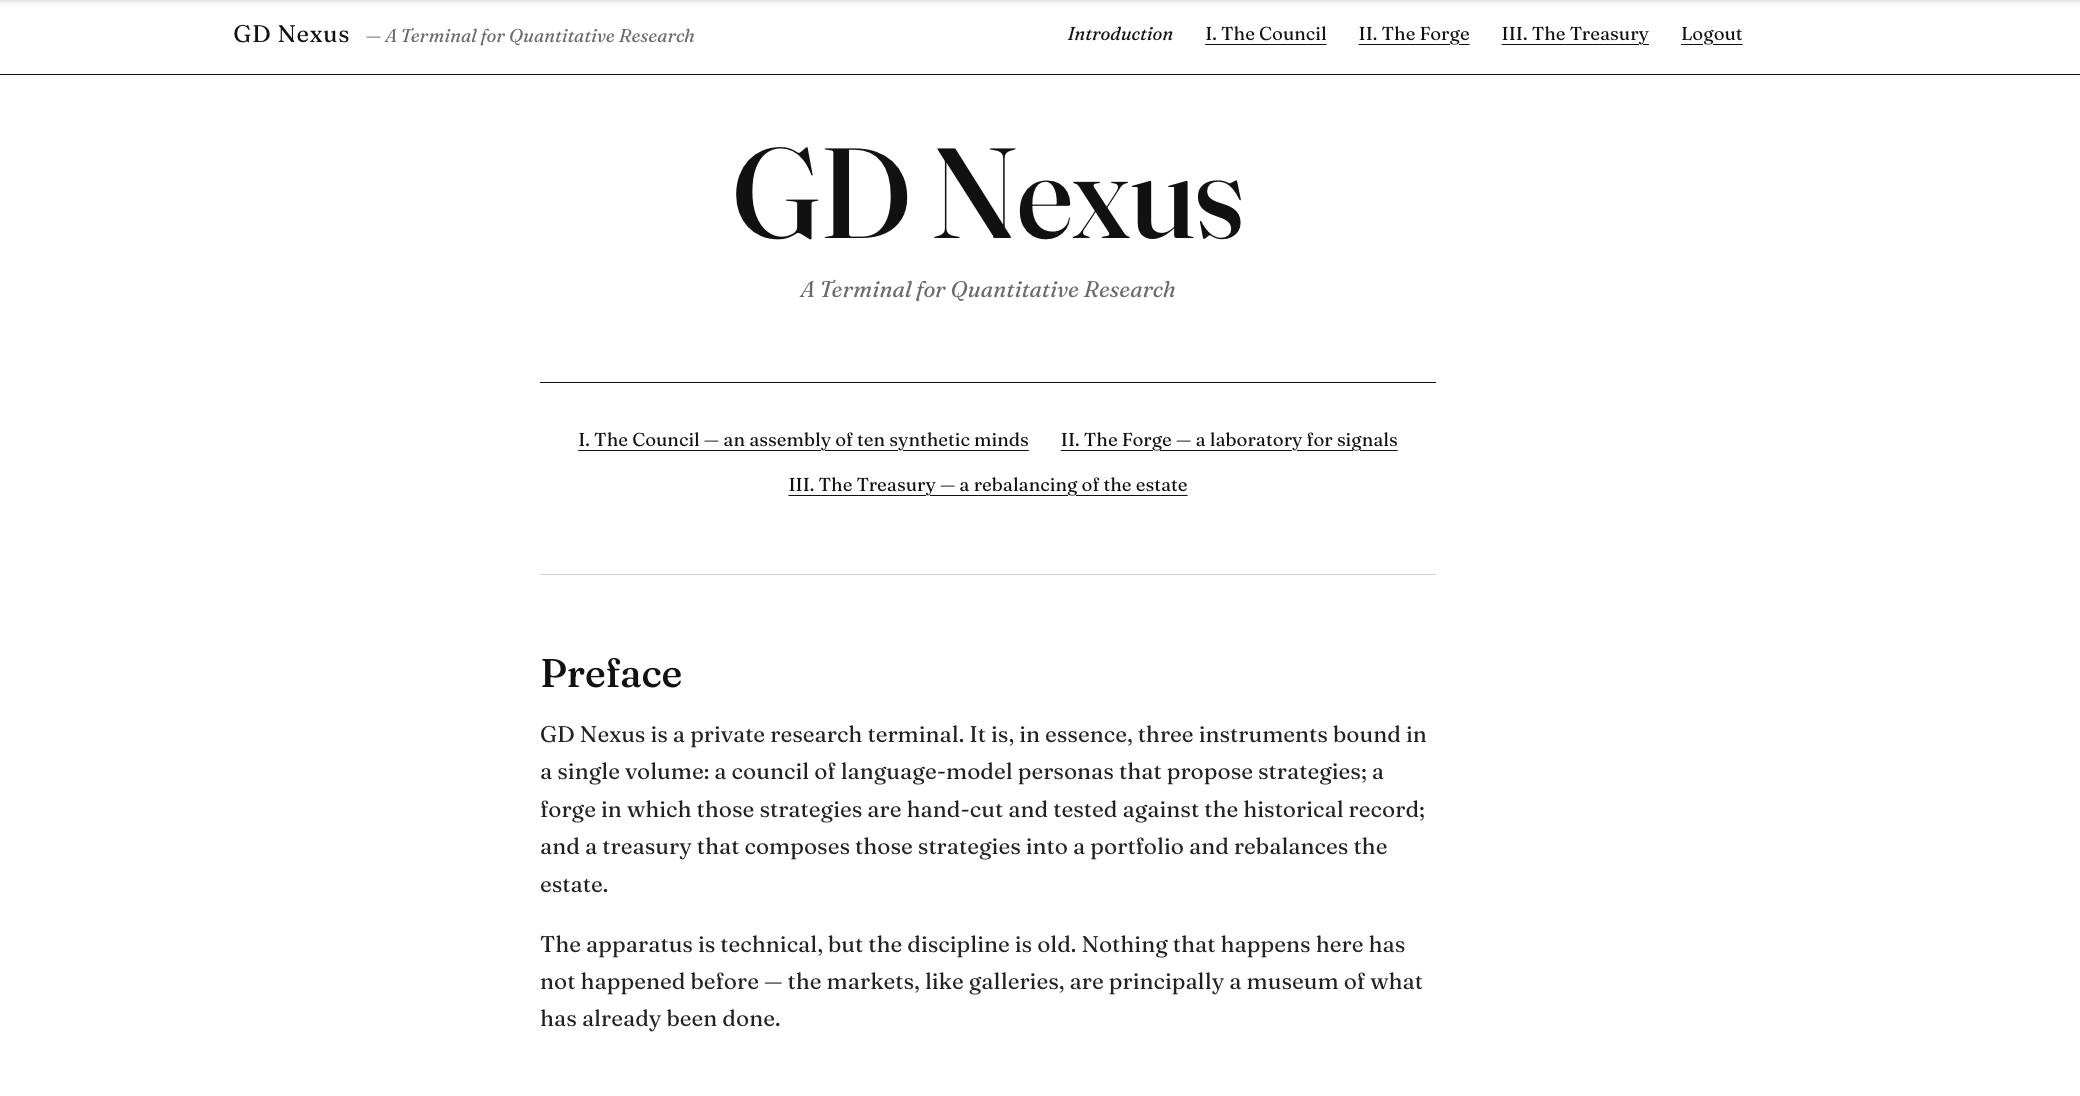

> "The apparatus is technical, but the discipline is old. Nothing that happens here has not happened before — the markets, like galleries, are principally a museum of what has already been done."

The interface deliberately avoids dashboard-style UI in favor of a single-column, editorial document — the system is read like a research notebook, chapter by chapter (Council → Forge → Treasury), rather than clicked through like a SaaS product.


## Architecture

```
┌─────────────────────────────────────────────────────────────────┐
│                          I. THE COUNCIL                           │
│   10 LLM research personas × 2 runs each = 20 attempts/session    │
│   Local inference (Ollama / Qwen3-8B) — nothing leaves the machine│
│                                                                     │
│   persona → IDEA → FORMULA → CODE → validate → backtest           │
│                                          │                         │
│                              ┌───────────┴──────────┐              │
│                          survivors               graveyard         │
│                       (promoted to vault)     (logged, not hidden) │
└─────────────────────────────────┬─────────────────────────────────┘
                                   │
┌──────────────────────────────────▼────────────────────────────────┐
│                           II. THE FORGE                             │
│   Sandboxed strategy execution + vectorized backtesting engine      │
│   yfinance data · lookahead detection · costs · leverage · SL/TP    │
│   → equity curve, drawdown, trade log, full metric suite            │
└──────────────────────────────────┬────────────────────────────────┘
                                   │
┌──────────────────────────────────▼────────────────────────────────┐
│                          III. THE TREASURY                          │
│   Portfolio analytics · Mean-Variance & Hierarchical Risk Parity    │
│   THE FUSION: run a vaulted strategy on the portfolio's own         │
│   combined equity curve — trade the estate, not just one asset      │
└─────────────────────────────────────────────────────────────────────┘
```


---

## I. The Council

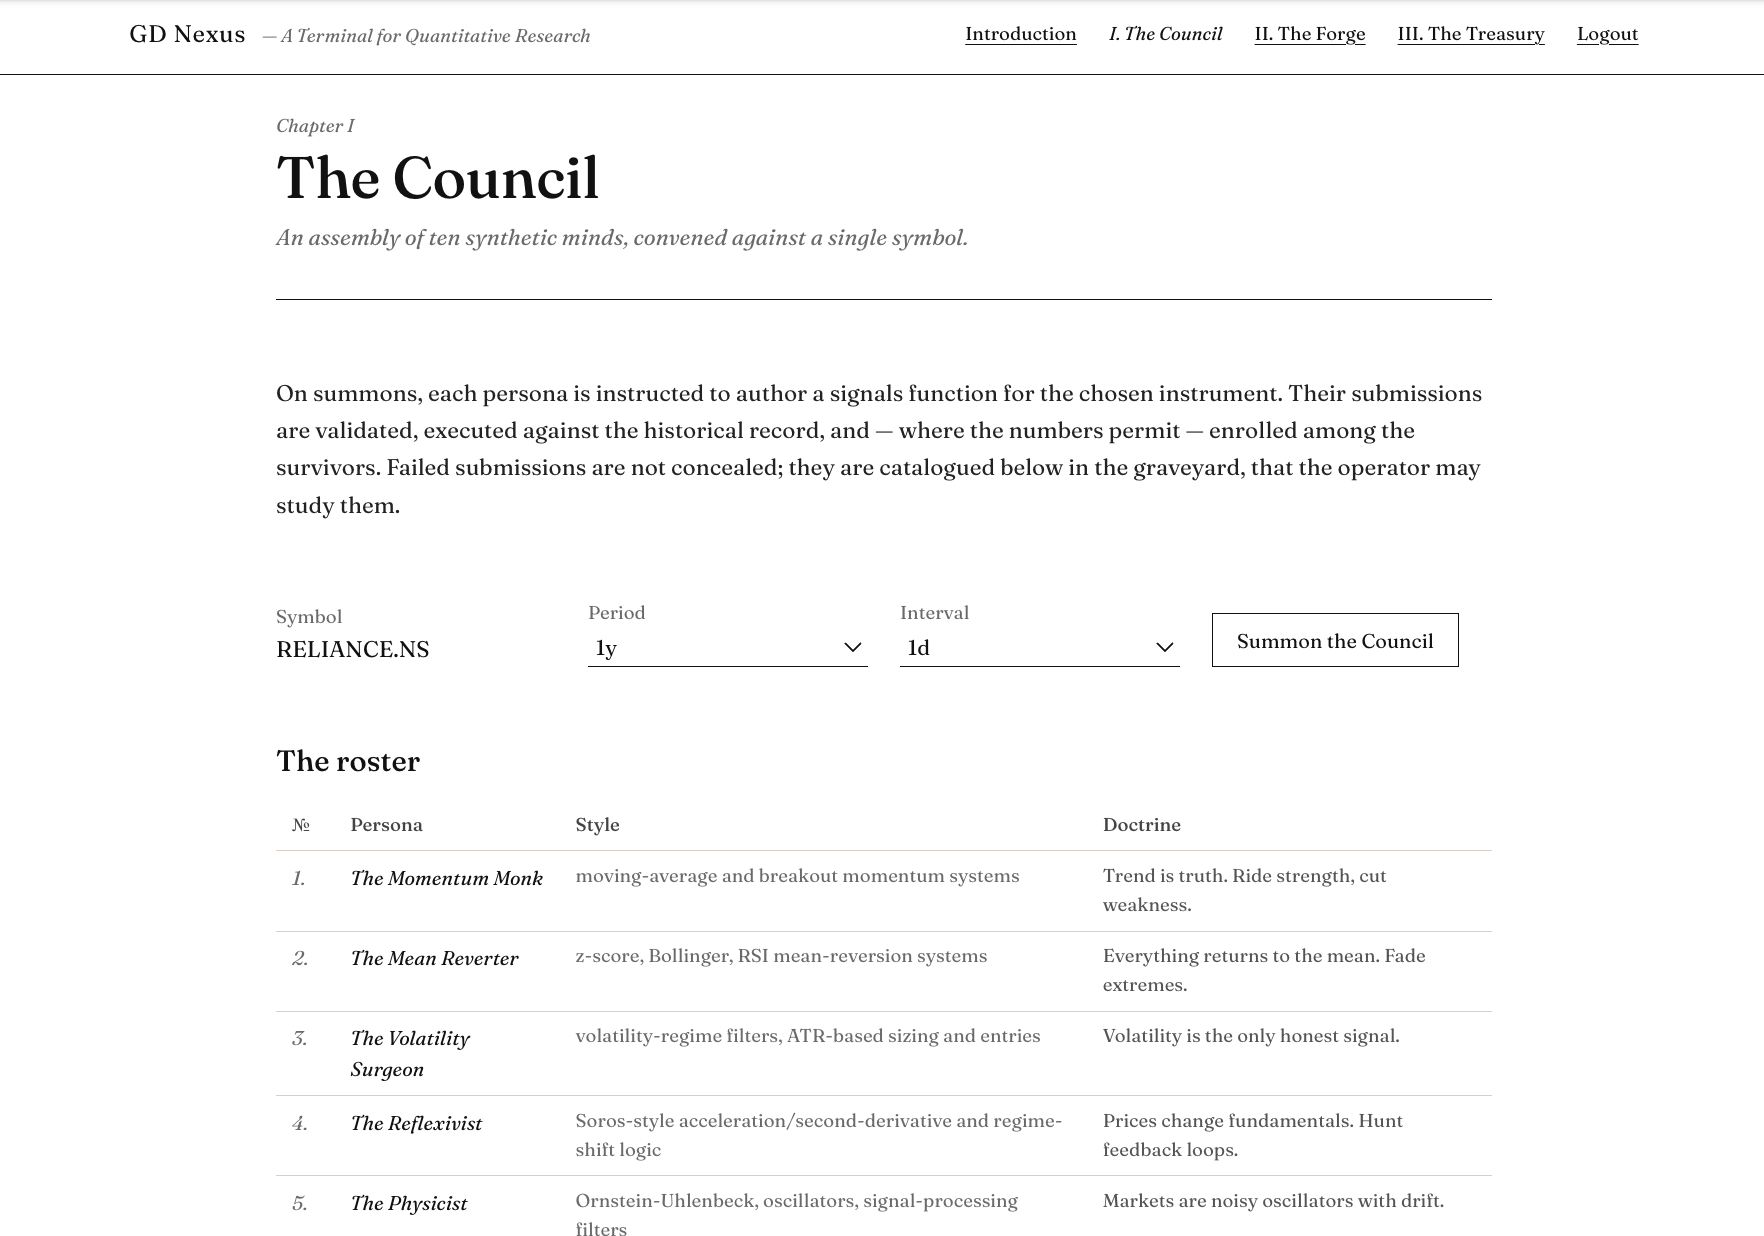

Ten research personas, each carrying a distinct doctrine rather than a generic "trading bot" prompt:

| # | Persona | Research Style |
|---|---------|-----------------|
| 1 | `physicist_stat_mech` | Statistical mechanics / information theory — rare-event detection, rolling Shannon entropy regime shifts |
| 2 | `physicist_wave_dynamics` | Signal processing — Hilbert transform instantaneous phase & frequency, cycle-state detection |
| 3 | `physicist_disordered_systems` | Regime-change detection — CUSUM change-point accumulation, continuous arctan scaling |
| 4 | `mathematician_stochastic` | Ornstein-Uhlenbeck parameter estimation via rolling OLS — reversion speed, half-life sizing |
| 5 | `mathematician_topology_geometry` | Differential geometry — Savitzky-Golay derivatives, true path curvature κ = y″/(1+y′²)^1.5 |
| 6 | `quant_stat_arb` | Statistical arbitrage — synthetic fair-value spread, half-life-gated mean reversion |
| 7 | `quant_vol_surface` | Garman-Klass OHLC volatility, regime-gated momentum/reversion switching |
| 8 | `quant_ml_engineer` | Orthogonal feature ensemble — z-scored momentum + mean-reversion + volume-confidence |
| 9 | `quant_behavioral` | Behavioral finance — disposition-effect proxy via distance-from-extremes |
| 10 | `quant_macro_regime` | 2×2 Hurst-exponent × volatility-percentile quadrant allocator, including a "go flat" regime |

**The pipeline, per persona, per run** (2 runs × 10 personas = 20 attempts per session):

1. The persona is prompted for an **IDEA** (the market inefficiency being targeted), a **FORMULA** (the governing math, in plain notation), and **CODE** — a `signals(df, params=None)` function returning positions in `[-1, 1]`.
2. Code is validated against a hard contract: no imports, no file/network access, no lookahead (`shift(-1)` is explicitly banned and checked for statically).
3. Validated code is executed against real historical OHLCV data inside a restricted sandbox (whitelisted builtins only, hard timeout).
4. Successful strategies are backtested immediately and their metrics attached to the result.

Below is the actual persona roster and prompt contract from the orchestrator:


In [ ]:
# engine/llm.py — persona roster (excerpt)

PERSONAS = [
    {"id": "physicist_stat_mech",
     "philosophy": "Price moves are a physical system: rare-event detection, "
                   "anomalous diffusion, entropy as disorder.",
     "style": "statistical mechanics / information theory — z-score outlier events, "
              "rolling Shannon entropy regime shifts"},

    {"id": "mathematician_topology_geometry",
     "philosophy": "The log-price path is a curve; its true differential curvature "
                   "marks structural turning points.",
     "style": "differential geometry — Savitzky-Golay smooth derivatives, "
              "curvature kappa = y''/(1+y'^2)^1.5"},

    {"id": "quant_macro_regime",
     "philosophy": "Classify the regime first, then deploy the strategy that regime "
                   "deserves — including none.",
     "style": "2x2 Hurst-exponent x volatility-percentile quadrant matrix with "
              "per-quadrant strategy switching"},
    # ... 7 more personas, each with an independent mathematical worldview
]

SYSTEM = (
    "You are {name}, a quantitative researcher. Worldview: {philosophy}\n"
    "Your research style: {style}.\n"
    "Design ONE original trading strategy from your worldview.\n"
    "HARD CONTRACT:\n"
    "- Define exactly: def signals(df, params=None)\n"
    "- Return a pandas Series aligned to df.index with values in [-1, 1]\n"
    "- df columns: Open, High, Low, Close, Volume\n"
    "- ONLY use pd, np, math (already in scope). NO imports.\n"
    "- Never use shift(-1) or any future data.\n"
    "Respond in EXACTLY this format:\n"
    "IDEA: <2-3 sentences: what you are trying to exploit and why>\n"
    "FORMULA: <the core math, in compact plain-text notation>\n"
    "```python\n<complete code>\n```"
)

**Nothing is hidden.** Every attempt — including the majority that fail — streams live with its stated idea, its formula, its exact code, and its exact error. The idea and formula are stamped as comments directly into the code artifact, so a failed run is still legible on its own:


In [ ]:
# A real failed attempt from the graveyard — mathematician_topology_geometry, run 1

# IDEA: Treat the log-price path as a curve; sharp curvature marks a turning point.
# FORMULA: kappa = y'' / (1 + y'^2)^1.5, via Savitzky-Golay smoothed derivatives
def signals(df, params=None):
    log_close = np.log(df["Close"])
    y_prime = scipy.signal.savgol_filter(log_close, window=11, deriv=1)
    y_double_prime = scipy.signal.savgol_filter(log_close, window=11, deriv=2)
    kappa = y_double_prime / (1 + y_prime**2)**1.5
    significant_bends = pd.Series(np.where(kappa.abs() > threshold, ...))
    # ^ ERROR: 'numpy.ndarray' object has no attribute 'abs'
    # savgol_filter returns a raw ndarray, not a Series — .abs() doesn't exist on it.
    # Fix: wrap with np.abs(kappa), or cast to pd.Series first.
    # The formula itself is correct; this is a one-line implementation bug.

Other real failure modes surfaced by the graveyard during development:

- `pandas.Rolling` has no `.zscore()` method — must be computed manually as `(x - x.rolling(N).mean()) / x.rolling(N).std()`
- `scipy.signal.hilbert` returns a raw `ndarray`, not a `Series`, so a chained `.diff()` call fails immediately after
- `np.diff()` silently shortens arrays by one element, causing `"Length of values does not match length of index"` errors downstream
- Models occasionally attempt `shift(-1)` to "peek" at the next bar — this is caught by a static lookahead check and rejected before the code ever reaches a backtest

Below is the sandbox itself — the part of the system that assumes every generated strategy is untrusted by default:


In [ ]:
# engine/backtest.py — execution sandbox (excerpt)

BANNED = ["import", "open(", "exec", "eval", "__", "os.", "sys.", "subprocess",
          "socket", "requests", "urllib", "shutil", "pathlib", "globals", "locals",
          "getattr", "setattr", "compile", "input(", "breakpoint"]

def validate_code(code: str) -> tuple[bool, str | None]:
    low = code.lower()
    for b in BANNED:
        if b in low:
            return False, f"Banned token: '{b}'"
    if "def signals" not in code:
        return False, "Missing `def signals(df, params=None)`"
    try:
        compile(code, "<strategy>", "exec")
    except SyntaxError as e:
        return False, f"SyntaxError: {e}"
    return True, None


def _run_signals(code: str, df: pd.DataFrame) -> pd.Series:
    safe_builtins = {"len": len, "range": range, "min": min, "max": max, "abs": abs,
                      "sum": sum, "float": float, "int": int, "bool": bool,
                      "round": round, "enumerate": enumerate, "zip": zip,
                      "list": list, "dict": dict, "print": lambda *a, **k: None}
    env = {"pd": pd, "np": np, "math": math, "__builtins__": safe_builtins}
    exec(compile(code, "<strategy>", "exec"), env)
    fn = env["signals"]
    sig = fn(df.copy(), None)
    return sig.reindex(df.index).fillna(0.0).clip(-1, 1).astype(float)

# executed with a hard timeout via a single-worker thread pool,
# so a runaway strategy cannot hang the pipeline

---

## II. The Forge

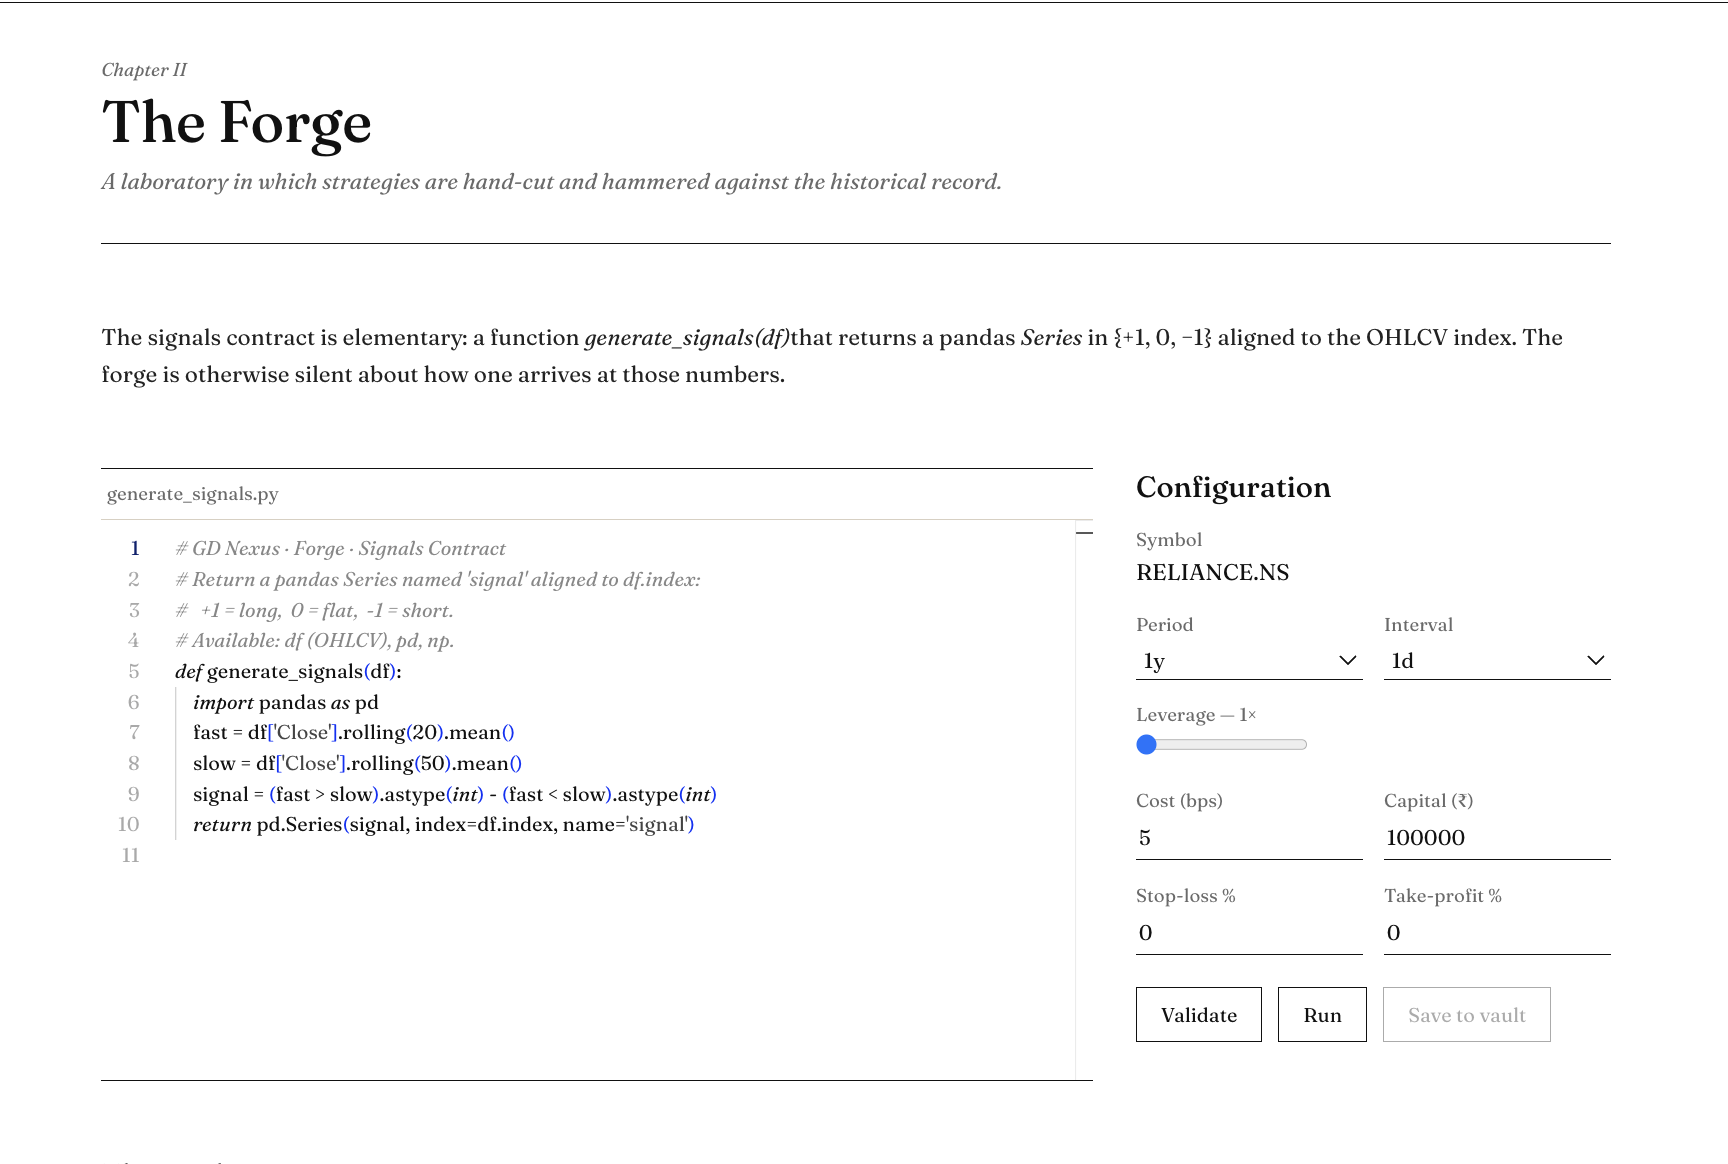

The backtesting laboratory. Every strategy — whether hand-written or council-generated — is held to the same contract:

```python
def signals(df, params=None) -> pd.Series
# returns positions in {-1, 0, +1} aligned to df.index
# +1 = long, -1 = short, 0 = flat
# df columns available: Open, High, Low, Close, Volume
```

**Execution safety:** sandboxed exec environment with restricted builtins and a banned-token filter, code compiled and validated *before* it ever touches live data, and positions are shifted forward one bar before being applied to returns — no accidental lookahead in the backtest math itself.

**What gets computed:** total return, CAGR, Sharpe ratio, max drawdown, volatility, win rate, trade count, full equity curve vs. buy-and-hold benchmark, drawdown series, and a complete trade log. Configurable transaction costs (bps), leverage (1–10×), stop-loss, and take-profit. Strategies can be run at 1mo–max lookback windows across 5m/15m/1h/1d bars, on any Yahoo Finance-listed instrument.


In [ ]:
# engine/backtest.py — the core backtest loop (excerpt)

def backtest(code, symbol, period="1y", interval="1d", capital=500_000.0,
             cost_bps=10.0, leverage=1.0, stop_loss=0.0, take_profit=0.0) -> dict:
    df = fetch_data(symbol, period, interval)
    sig = run_signals_timeboxed(code, df)          # sandboxed, hard-timeout execution
    pos = sig.shift(1).fillna(0.0)                  # trade NEXT bar — no lookahead
    if stop_loss or take_profit:
        pos = _apply_sl_tp(df, pos, stop_loss, take_profit)

    ret = df["Close"].pct_change().fillna(0.0)
    turnover = pos.diff().abs().fillna(pos.abs())
    strat_ret = pos * ret * leverage - turnover * (cost_bps / 10_000) * leverage

    equity = capital * (1 + strat_ret).cumprod()
    bench  = capital * (1 + ret).cumprod()
    dd = equity / equity.cummax() - 1

    sharpe = (strat_ret.mean() / strat_ret.std() * np.sqrt(252)) if strat_ret.std() > 0 else 0.0
    cagr   = (equity.iloc[-1] / capital) ** (252 / len(equity)) - 1

    return {
        "metrics": {"cagr": round(cagr * 100, 2), "sharpe": round(float(sharpe), 2),
                    "max_drawdown": round(float(dd.min()) * 100, 2), ...},
        "equity": [...], "benchmark": [...], "drawdown": [...], "trades": [...],
    }

---

## III. The Treasury

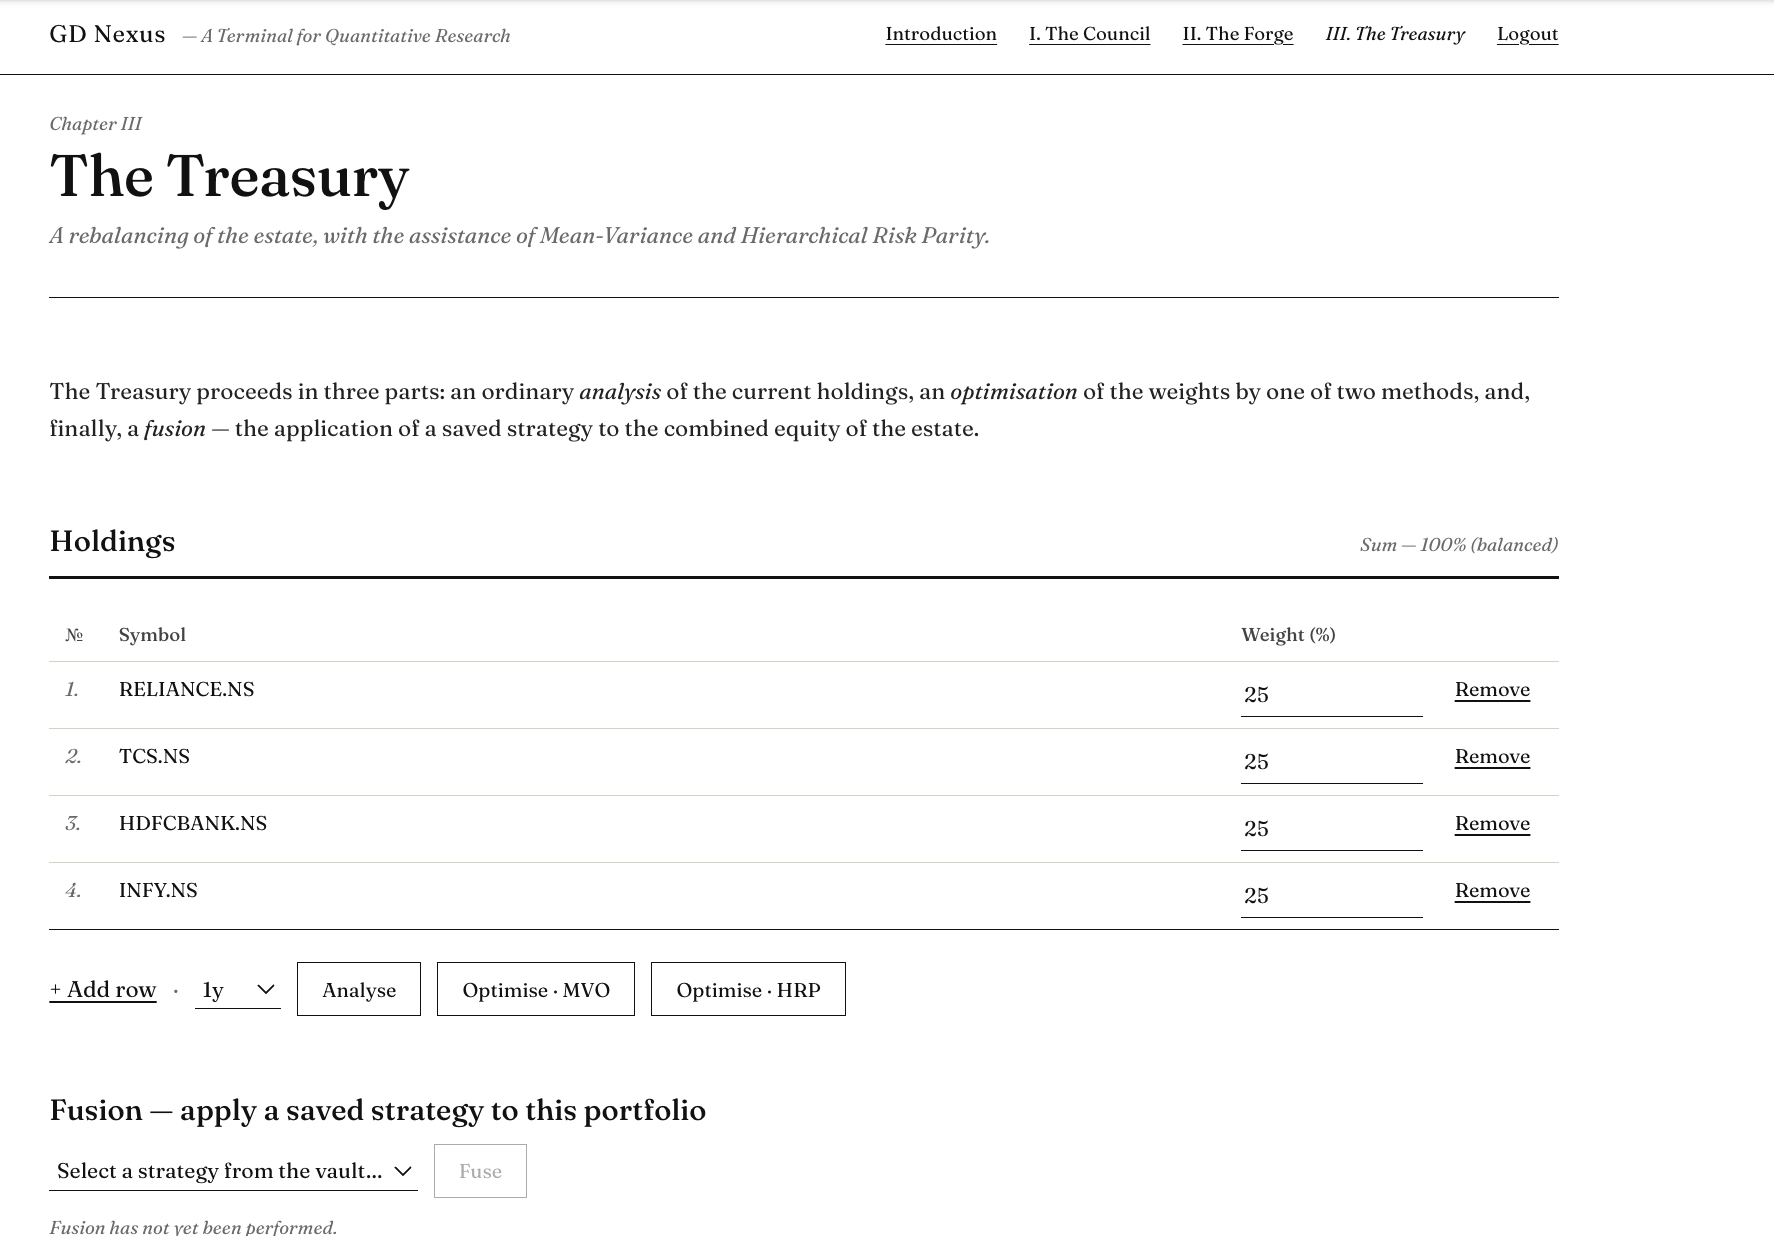

Portfolio construction, and the system's actual thesis: **strategies shouldn't just trade one instrument — they should be tested against a real, allocated portfolio.**

**Three operations:**

1. **Analyze** — given a set of holdings and weights, compute portfolio-level return, volatility, Sharpe, drawdown, and a full pairwise correlation matrix.
2. **Optimize** — rebalance the same holdings using either **Mean-Variance Optimization (MVO)**, which maximizes Sharpe ratio via constrained SLSQP over the covariance matrix, or **Hierarchical Risk Parity (HRP)**, which clusters assets by correlation distance (single-linkage) and allocates inverse-variance weight recursively down the dendrogram — avoiding the instability MVO exhibits under estimation error.
3. **Fusion** — the connective operation. A strategy pulled from the Council's vault is run not against a single stock, but against the **portfolio's own weighted combined equity curve**, treated as a synthetic instrument. This answers a different question than a single-asset backtest: *does this strategy add value on top of my actual diversified book, net of costs?*


In [ ]:
# engine/portfolio.py — MVO, HRP, and the fusion (excerpts)

def _mvo(rets: pd.DataFrame) -> np.ndarray:
    """Maximize Sharpe ratio subject to full investment, long-only."""
    mu, cov, n = rets.mean().values * 252, rets.cov().values * 252, rets.shape[1]

    def neg_sharpe(w):
        v = np.sqrt(w @ cov @ w)
        return -(w @ mu) / v if v > 0 else 0.0

    res = minimize(neg_sharpe, np.ones(n) / n, method="SLSQP",
                    bounds=[(0.0, 1.0)] * n,
                    constraints=[{"type": "eq", "fun": lambda w: w.sum() - 1}])
    return res.x


def _hrp(rets: pd.DataFrame) -> np.ndarray:
    """Hierarchical Risk Parity — cluster by correlation distance, allocate
    inverse-variance weight recursively down the dendrogram."""
    corr, cov = rets.corr().values, rets.cov().values
    dist = np.sqrt(np.clip((1 - corr) / 2, 0, 1))
    order = list(leaves_list(linkage(squareform(dist, checks=False), method="single")))
    # ... recursive bisection, inverse-variance split between each cluster pair
    return weights


def portfolio_backtest(holdings, code, period="1y", ...) -> dict:
    """THE FUSION: build the weighted portfolio as a synthetic asset,
    then run the strategy's signals on that synthetic asset."""
    px = _prices(holdings, period, interval)
    w = _weights(holdings)
    rets = (px.pct_change().fillna(0.0) * w).sum(axis=1)      # combined portfolio return
    synth_close = capital * (1 + rets).cumprod()                # portfolio AS an instrument

    df = pd.DataFrame({"Open": synth_close.shift(1), "High": synth_close,
                        "Low": synth_close, "Close": synth_close,
                        "Volume": np.ones(len(synth_close))})
    sig = run_signals_timeboxed(code, df)                       # same sandbox, same contract
    pos = sig.shift(1).fillna(0.0)
    strat_ret = pos * rets - pos.diff().abs() * (cost_bps / 10_000)
    equity = capital * (1 + strat_ret).cumprod()
    return {"metrics": ..., "equity": ..., "benchmark": ...}

---

## Engineering notes

- **Fully local.** LLM inference runs on-device via Ollama (Qwen3-8B) — no API costs, no data leaves the machine, no rate limits on strategy generation.
- **Failure is a first-class citizen.** The graveyard is not a debug log bolted on after the fact — the event schema (`stage`, `persona_start`, `code`, `validation_failed`, `runtime_error`, `backtested`, `done`) treats success and failure as equally structured, equally displayed outcomes.
- **No lookahead, enforced twice.** Once at the persona-prompt level (explicit instruction plus a static check for `shift(-1)`), and again structurally in the backtest engine itself (signals are shifted forward before being applied to returns) — so a strategy cannot accidentally cheat even if the first check is somehow bypassed.
- **Sandboxing over trust.** Generated code runs with a whitelisted builtin set and a banned-token filter rather than relying on the model to behave — untrusted output is the default assumption, not an edge case.

## Status

Personal research tool, actively developed. Paper trading only — not investment advice, not a production trading system.
